In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

In [2]:
def preprocess_data(data, interval, data_size):

    df = pd.DataFrame(data["values"])

    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
        df.set_index('datetime', inplace=True)

    df.drop(columns=["high", "low", "close", "volume"], inplace=True, errors='ignore')

    freq_map = {
        "1day": "D",
        "1hour": "H",
        "5min": "5T"
    }

    full_index = pd.date_range(
        start=df.index.min(),
        end=df.index.max(),
        freq=freq_map[interval]
    )

    # Ресемплируем данные по новому индексу
    df = df.reindex(full_index)

    # Комбинируем методы: сначала интерполяция, затем заполнение последним значением
    df['open'] = df['open'].interpolate(method='time').ffill().bfill()
    ts = pd.Series(df['open'], index=df.index, name="value")

    return ts

In [3]:
def get_data(symbol , interval, outputsize, apikey): #функция получения данных с API
  params = {
    "symbol": symbol,
    "interval": interval,
    "outputsize": outputsize,
    "apikey": api_key
  }

  url = "https://api.twelvedata.com/time_series"
  data = requests.get(url, params=params).json()

  df = preprocess_data(data, interval, outputsize)

  return df

In [4]:
api_key = "5326f043daec4329a7041b579b9aaa53"

symbol = "AAPL"
interval = "1day"
outputsize = "100"

df = get_data(symbol, interval, outputsize, api_key)
df.head()

{'meta': {'symbol': 'AAPL', 'interval': '1day', 'currency': 'USD', 'exchange_timezone': 'America/New_York', 'exchange': 'NASDAQ', 'mic_code': 'XNGS', 'type': 'Common Stock'}, 'values': [{'datetime': '2025-04-10', 'open': '189.065', 'high': '194.75', 'low': '183', 'close': '190.49', 'volume': '6282527'}, {'datetime': '2025-04-09', 'open': '171.95000', 'high': '200.61000', 'low': '171.89000', 'close': '198.85001', 'volume': '184067400'}, {'datetime': '2025-04-08', 'open': '186.70000', 'high': '190.34000', 'low': '169.21001', 'close': '172.42000', 'volume': '120859500'}, {'datetime': '2025-04-07', 'open': '177.20000', 'high': '194.14999', 'low': '174.62000', 'close': '181.46001', 'volume': '160466300'}, {'datetime': '2025-04-04', 'open': '193.89000', 'high': '199.88000', 'low': '187.34000', 'close': '188.38000', 'volume': '125910900'}, {'datetime': '2025-04-03', 'open': '205.53999', 'high': '207.49001', 'low': '201.25', 'close': '203.19000', 'volume': '103419000'}, {'datetime': '2025-04-0

<ipython-input-2-b1b8b8b82543>:33: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df['open'] = df['open'].interpolate(method='time').ffill().bfill()


,value
2024-11-14,225.020004
2024-11-15,226.39999
2024-11-16,226.39999
2024-11-17,226.39999
2024-11-18,225.25


In [5]:
ts = df.astype(float)

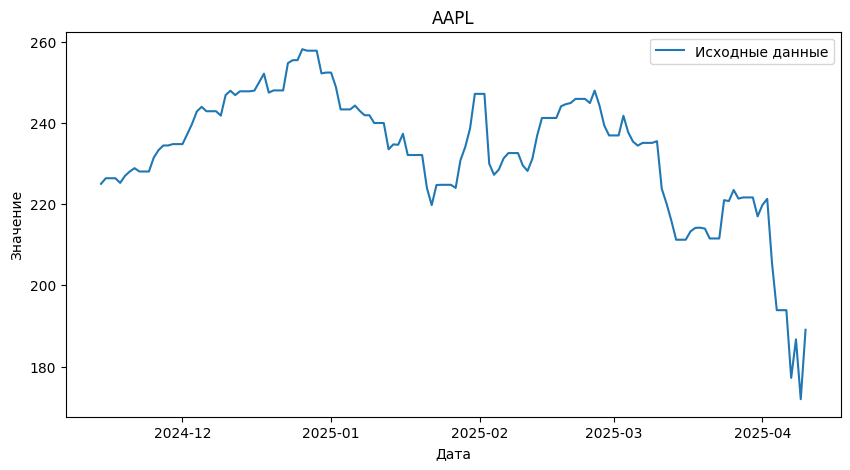

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(ts, label="Исходные данные")
plt.title("AAPL")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend()
plt.show()

Проверим данные на тесте Дики-Фуллера

In [7]:
from statsmodels.tsa.stattools import adfuller
p_value = adfuller(ts)[1]
print(f"ADF p-value: {p_value}")

ADF p-value: 0.8092157098105167


In [9]:
from pmdarima import auto_arima

forecast_steps = 10
model = auto_arima(
    ts[:-forecast_steps],
    seasonal=False,
    stepwise=True,
    trace=True
)
print(model.summary())

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
forecast, conf_int = model.predict(
    n_periods=forecast_steps,
    return_conf_int=True  # Возвращает доверительные интервалы
)

forecast

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,0
2025-03-31,221.67
2025-04-01,221.67
2025-04-02,221.67
2025-04-03,221.67
2025-04-04,221.67
2025-04-05,221.67
2025-04-06,221.67
2025-04-07,221.67
2025-04-08,221.67
2025-04-09,221.67


In [11]:
forecast_steps = 100

model = ARIMA(ts[:-forecast_steps], order=(2, 2, 2))
result = model.fit()

print(result.summary()) #выведем summary модели

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                   48
Model:                 ARIMA(2, 2, 2)   Log Likelihood                 -96.604
Date:                Thu, 10 Apr 2025   AIC                            203.207
Time:                        20:21:38   BIC                            212.350
Sample:                    11-14-2024   HQIC                           206.632
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8471      0.319     -2.658      0.008      -1.472      -0.223
ar.L2         -0.0952      0.276     -0.344      0.731      -0.637       0.447
ma.L1         -0.0002     63.236  -3.02e-06      1.0

In [12]:
# Прогноз на 10 шагов вперед
result = model.fit()
forecast = result.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
confidence_interval = forecast.conf_int()

forecast.predicted_mean

,predicted_mean
2025-01-01,253.819163
2025-01-02,253.798282
2025-01-03,254.852061
2025-01-04,255.128790
2025-01-05,255.961443
...,...
2025-04-06,310.559286
2025-04-07,311.160323
2025-04-08,311.761359
2025-04-09,312.362396


In [13]:
forecast_mean

,predicted_mean
2025-01-01,253.819163
2025-01-02,253.798282
2025-01-03,254.852061
2025-01-04,255.128790
2025-01-05,255.961443
...,...
2025-04-06,310.559286
2025-04-07,311.160323
2025-04-08,311.761359
2025-04-09,312.362396


In [14]:
#Вычисление MAE
actual_values = ts.values[-forecast_steps:]
predicted_values = forecast_mean.values

mae = np.mean(np.abs(predicted_values - actual_values))
print(f"MAE: {mae:.2f}")

MAE: 54.57


AttributeError: 'PredictionResults' object has no attribute 'index'

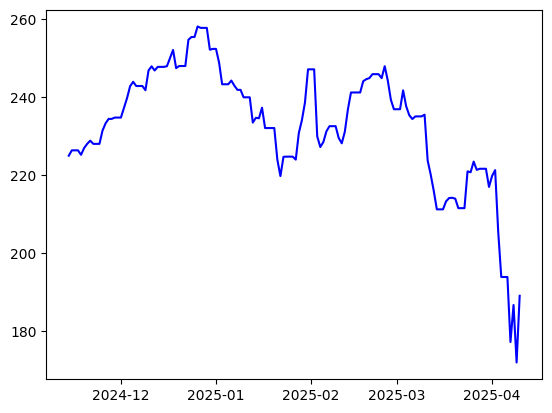

In [15]:
plt.plot(ts.index, ts.values, label='Real Data', color='blue')

# Прогнозы
plt.plot(forecast.index, forecast_mean.values, label='ARIMA Forecast', color='red', linestyle='--')

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:, 0],
    confidence_interval.iloc[:, 1],
    color='pink',
    alpha=0.3,
    label='Confidence Interval'
)

plt.title('ARIMA Forecast vs Actual Data')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Форматирование дат на оси X
plt.gcf().autofmt_xdate()

plt.show()